In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib
import matplotlib.pyplot as plt
import pertpy as pt
import scanpy as sc
import pandas as pd
import seaborn as sb

plt.rcParams["figure.figsize"] = (7, 7)
import numpy as np

sc.settings.verbosity = 3


import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.7,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

## r2py setup
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

## Define color palette
pal = sb.color_palette('Paired').as_hex()
design_palette = {'ACR':pal[3], 'CR':pal[7], 'AR':pal[9], 'joint_CR':pal[6]}
design_palette_df = pd.DataFrame(design_palette.values(), index =design_palette.keys() )
design_palette_df.columns = ['color']

import os,sys

figdir = './sysVI_mm_OL_figures/'
if not os.path.exists(figdir):
    os.mkdir(figdir)
sc.settings.figdir = figdir

In [2]:
%%R
library(tidyverse)
library(reshape2)
library(patchwork)
library(ggrastr)
library(shadowtext)

remove_x_axis <- function(){
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), axis.title.x = element_blank())  
}

remove_y_axis <- function(){
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.title.y = element_blank())  
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘reshape2’

The following object is masked from ‘package:tidyr’:

    smiths



In [3]:
%%R -i design_palette_df -i figdir
design_palette = setNames(design_palette_df$color, rownames(design_palette_df))

In [4]:
from adjustText import adjust_text
import matplotlib.patheffects as pe

def gen_mpl_labels(
    adata, groupby, exclude=(), ax=None, adjust_kwargs=None, text_kwargs=None
):
    if adjust_kwargs is None:
        adjust_kwargs = {"text_from_points": False}
    if text_kwargs is None:
        text_kwargs = {}

    medians = {}

    for g, g_idx in adata.obs.groupby(groupby).groups.items():
        if g in exclude:
            continue
        medians[g] = np.median(adata[g_idx].obsm["X_umap"], axis=0)

    if ax is None:
        texts = [
            plt.text(x=x, y=y, s=k, **text_kwargs) for k, (x, y) in medians.items()
        ]
    else:
        texts = [ax.text(x=x, y=y, s=k, **text_kwargs) for k, (x, y) in medians.items()]

    adjust_text(texts, **adjust_kwargs)

In [5]:
def plot_w_ggplot(r_fct_str, args, figdir='.', pl_name='plot', pl_width=8, pl_height=8):

    import rpy2.robjects.pandas2ri
    import rpy2.robjects.numpy2ri
    from rpy2.robjects.packages import STAP

    r_pkg = STAP(r_fct_str, "r_pkg")
    #this was needed for the code to run on jhub
    #if you have a different version of rpy2 you may not need these two lines
    rpy2.robjects.pandas2ri.activate()
    rpy2.robjects.numpy2ri.activate()
    
    # PASS OBJECTS INTO FUNCTION
    pl = r_pkg.plot_func(args)
    
    ggsave_str = '''
    save_plot <- function(pl, figdir, pl_name, pl_width, pl_height){
        pl + 
        ggsave(file.path(figdir, paste0(pl_name, ".png")), width=pl_width, height=pl_height)  +
        ggsave(file.path(figdir, paste0(pl_name, ".pdf")), width=pl_width, height=pl_height)
    }
    
    '''
    r_save = STAP(ggsave_str, "r_save")
    r_save.save_plot(pl, figdir, pl_name=pl_name, pl_width=pl_width, pl_height=pl_height)

# Read in all files for beeswarm MILO plots

In [6]:
LD = pd.read_csv('./nh_df_LPC_demyel_NEW_KEEP_ALL.csv', index_col=1)  # index_col=0 to set the first column as the index
LD.shape

(3865, 12)

In [7]:
LR = pd.read_csv('./nh_df_LPC_remyel_NEW_KEEP_ALL.csv', index_col=1)  # index_col=0 to set the first column as the index
LR.shape

(3865, 12)

In [8]:
CD = pd.read_csv('./nh_df_Cupr_demyel_NEW_KEEP_ALL.csv', index_col=1)  # index_col=0 to set the first column as the index
CD.shape

(3865, 12)

In [9]:
CR = pd.read_csv('./nh_df_Cupr_remyel_NEW_KEEP_ALL.csv', index_col=1)  # index_col=0 to set the first column as the index
CR.shape

(3865, 12)

In [10]:
LD.head()

,Unnamed: 0,kth_distance,logFC,logCPM,F,PValue,FDR,SpatialFDR,Sig,Nhood_size,nhood_annotation,nhood_annotation_frac
index_cell,,,,,,,,,,,,
CTTGATTTCGTCCTTG-1_adams,0,4.803607,2.586868,8.765427,5.078038,0.025395,0.077959,0.072990,True,100.0,NFOLs,1.000000
CCACACTCACCTCAGG-1_adams,1,3.926955,1.420425,8.718165,1.423694,0.234379,0.352849,0.341323,False,108.0,MFOLs,0.972222
GTTTGGATCAAGAATG-1_adams,2,3.594900,1.877285,8.731116,2.578256,0.109968,0.207939,0.198639,False,113.0,MFOLs,1.000000
TCACGCTCACTACTTT-1_adams,3,3.296920,3.685002,9.203356,8.282761,0.004450,0.027174,0.025106,True,147.0,NFOLs,1.000000
TGAGGAGCAGGACTTT-1_adams,4,2.804393,2.192000,9.087255,3.263025,0.072411,0.155655,0.148120,False,158.0,MFOLs,1.000000


In [11]:
# Compare indices
ld_index = LD.index
lr_index = LR.index
cd_index = CD.index
cr_index = CR.index

# Check if all indices are the same
if ld_index.equals(lr_index) and ld_index.equals(cd_index) and ld_index.equals(cr_index):
    print("All DataFrames have the same index.")
else:
    print("The DataFrames do not have the same index.")

All DataFrames have the same index.


In [12]:
# Drop rows where the 'nhood_annotation' column has the value 'Mixed'
LD = LD[LD['nhood_annotation'] != 'Mixed']

# Check the shape after dropping the rows
LD.shape

(3280, 12)

In [13]:
# Drop rows where the 'nhood_annotation' column has the value 'Mixed'
LR = LR[LR['nhood_annotation'] != 'Mixed']

# Check the shape after dropping the rows
LR.shape

(3280, 12)

In [14]:
# Drop rows where the 'nhood_annotation' column has the value 'Mixed'
CD = CD[CD['nhood_annotation'] != 'Mixed']

# Check the shape after dropping the rows
CD.shape

(3280, 12)

In [15]:
# Drop rows where the 'nhood_annotation' column has the value 'Mixed'
CR = CR[CR['nhood_annotation'] != 'Mixed']

# Check the shape after dropping the rows
CR.shape

(3280, 12)

# Stacked barchart of proportions of gains and loses?

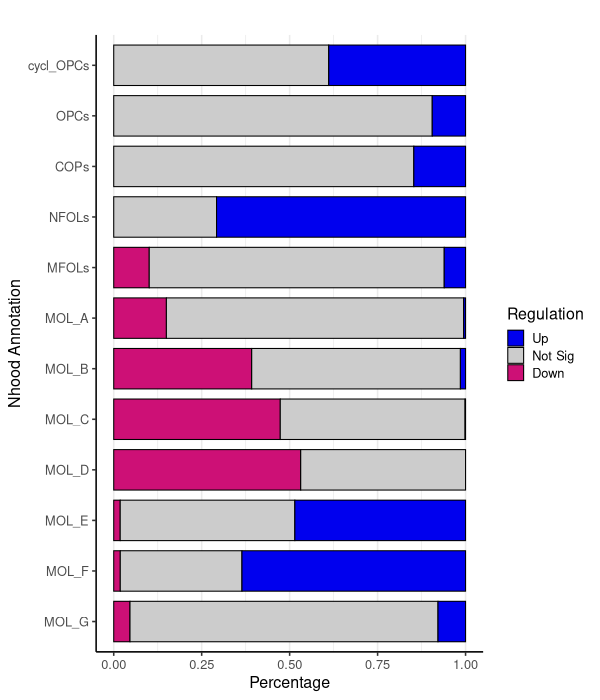

In [26]:
%%R -h 700 -w 600 -i LD

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- LD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Plot stacked bar chart
ggplot(plot_df, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Regulation"
  ) +
  theme_bw(base_size = 16) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right"
  ) +
  ylab("Percentage") +
  xlab("Nhood Annotation") +
  ggtitle("")

# Save the plot if needed
#ggsave(
#  paste0(figdir, "stacked_bar_sig_proportions_REVISION.png"),
#  width = 10,
#  height = 8
#)

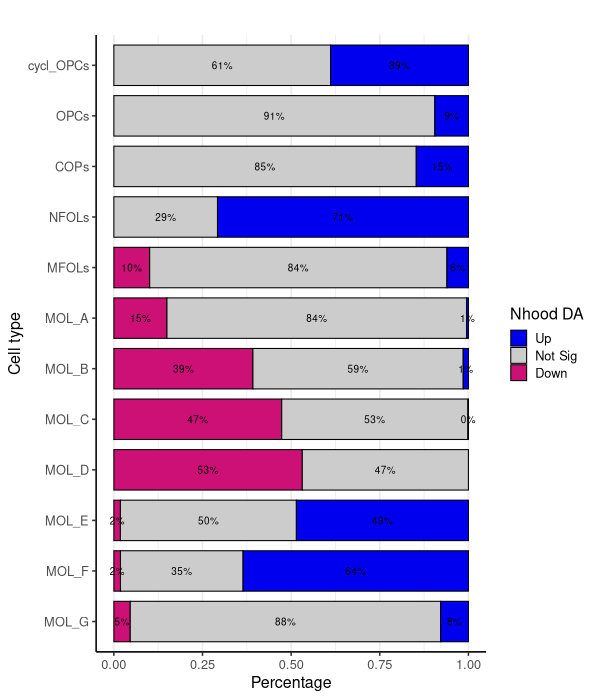

In [27]:
%%R -h 700 -w 600 -i LD

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- LD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
  geom_text(
    aes(
      y = midpoint,
      label = scales::percent(proportion, accuracy = 1)
    ),
    color = "black",
    size = 3.5
  ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 16) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right"
  ) +
  ylab("Percentage") +
  xlab("Cell type") +
  ggtitle("")

# Save the plot if needed
#ggsave(
#  paste0(figdir, "stacked_bar_sig_proportions_REVISION.png"),
#  width = 10,
#  height = 8
#)

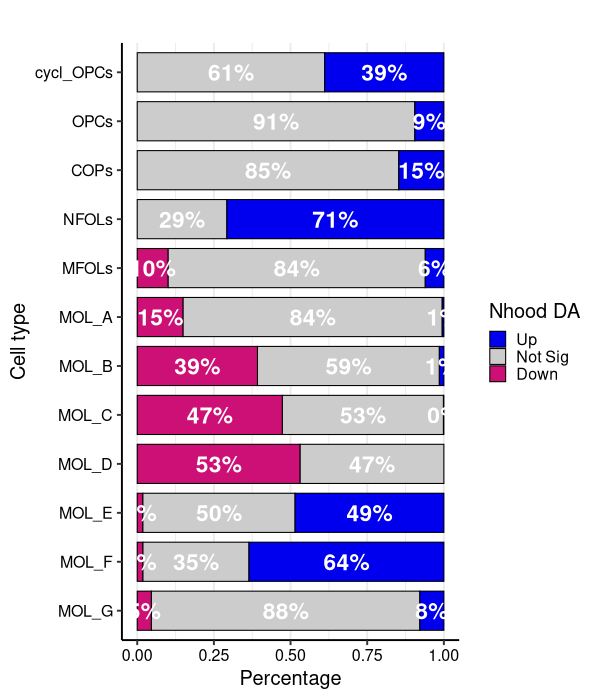

In [28]:
%%R -h 700 -w 600 -i LD

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- LD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
  geom_text(
    aes(
      y = midpoint,
      label = scales::percent(proportion, accuracy = 1)
    ),
    color = "white",
    size = 8,
    fontface = "bold"
  ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("Cell type") +
  ggtitle("")

# Save the plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_LPC_demyel.png"),
  plot = p,  # explicitly specify which plot to save
  width = 14,
  height = 10,
  dpi = 300
)

# Display the plot
print(p)

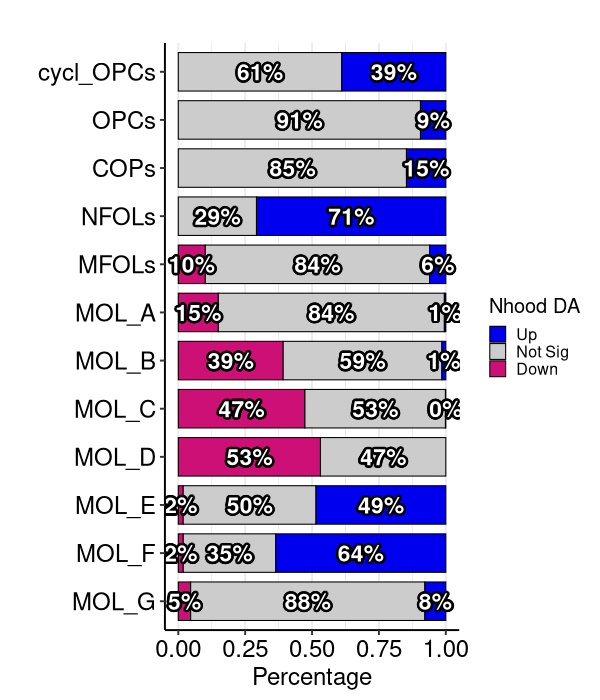

In [16]:
%%R -h 700 -w 600 -i LD

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- LD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.15,           # Radius of outline
      size = 8,
      fontface = "bold"
    ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("") +
  ggtitle("")

# Save the plot
#ggsave(paste0(figdir, "stacked_bar_sig_proportions_LPC_demyel.png"), plot = p, width = 14, height = 10, dpi = 300)

# Display the plot
print(p)

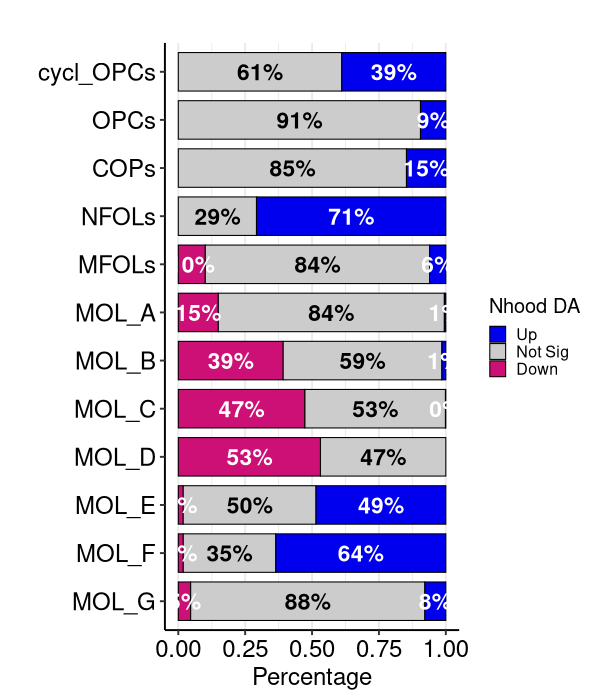

In [19]:
%%R -h 700 -w 600 -i LD

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- LD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Split into subsets for different label colors
labels_down <- plot_df_with_labels %>% filter(sig_status == "Down")
labels_up <- plot_df_with_labels %>% filter(sig_status == "Up")
labels_not_sig <- plot_df_with_labels %>% filter(sig_status == "Not Sig")

# Base plot
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +

  # Labels for "Down" - white text
  geom_text(
    data = labels_down,
    aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
    color = "white",
    size = 8,
    fontface = "bold"
  ) +

  # Labels for "Up" - white text
  geom_text(
    data = labels_up,
    aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
    color = "white",
    size = 8,
    fontface = "bold"
  ) +

  # Labels for "Not Sig" - black text
  geom_text(
    data = labels_not_sig,
    aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
    color = "black",
    size = 8,
    fontface = "bold"
  ) +

  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),
    axis.text.y = element_text(size = 24),
    axis.title.x = element_text(size = 24),
    axis.title.y = element_text(size = 24),
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("") +
  ggtitle("")

# Save
#ggsave(paste0(figdir, "stacked_bar_sig_proportions_LPC_demyel.png"), plot = p, width = 14, height = 10, dpi = 300)

# Display
print(p)

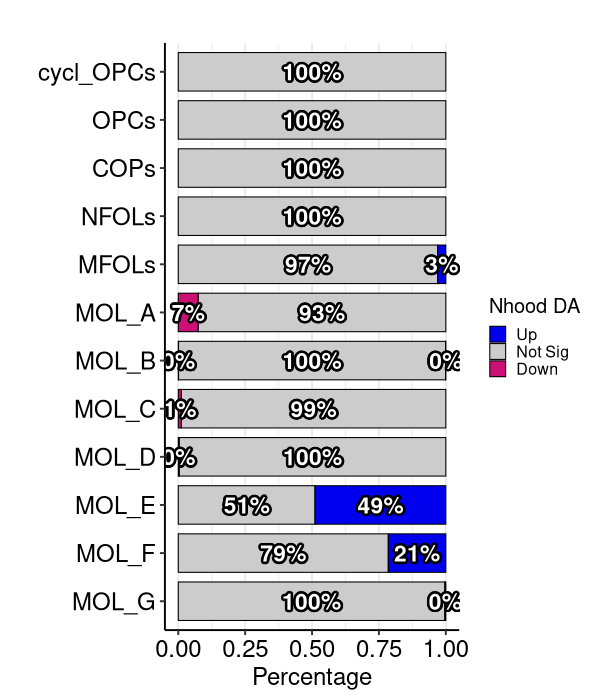

In [35]:
%%R -h 700 -w 600 -i LR

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- LR %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.15,           # Radius of outline
      size = 8,
      fontface = "bold"
    ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_LPC_remyel.png"),
  plot = p,  # explicitly specify which plot to save
  width = 14,
  height = 10,
  dpi = 300
)

# Display the plot
print(p)

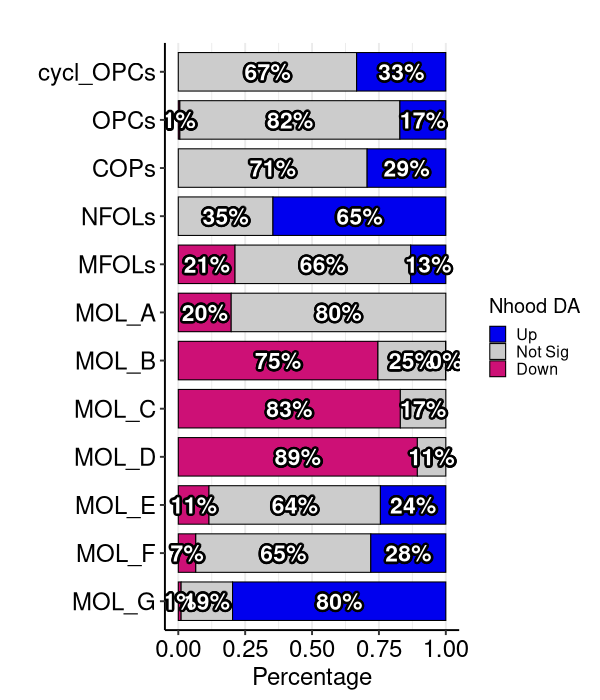

In [36]:
%%R -h 700 -w 600 -i CD

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- CD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.15,           # Radius of outline
      size = 8,
      fontface = "bold"
    ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_CPZ_demyel.png"),
  plot = p,  # explicitly specify which plot to save
  width = 14,
  height = 10,
  dpi = 300
)

# Display the plot
print(p)

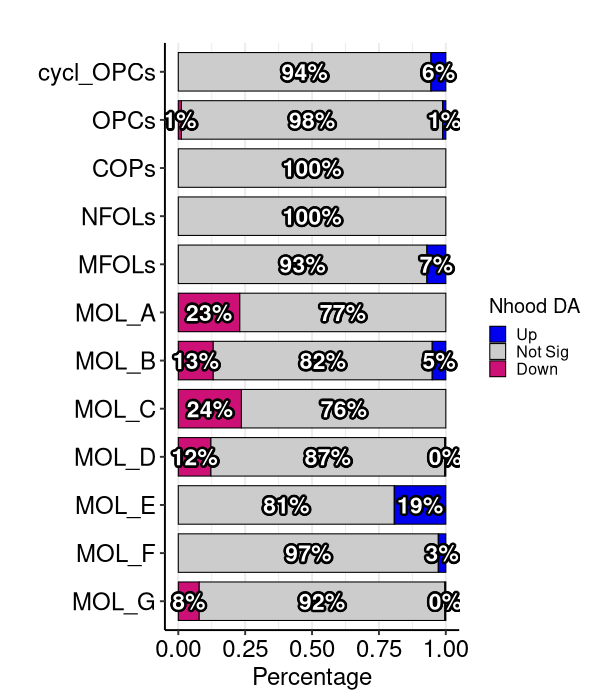

In [37]:
%%R -h 700 -w 600 -i CR

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- CR %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.15,           # Radius of outline
      size = 8,
      fontface = "bold"
    ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_CPZ_remyel.png"),
  plot = p,  # explicitly specify which plot to save
  width = 14,
  height = 10,
  dpi = 300
)

# Display the plot
print(p)

# Statistical testing on proportions

In [16]:
%%R

library(dplyr)
library(tidyr)
library(purrr)
library(broom)

In [17]:
%%R -h 700 -w 600 -i LD

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- LD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

LD_df <- plot_df_with_labels
head(LD_df)

# A tibble: 6 × 6
  nhood_annotation sig_status     n proportion cumulative midpoint
  <fct>            <fct>      <int>      <dbl>      <dbl>    <dbl>
1 MFOLs            Down          10     0.101      0.101   0.0505 
2 MOL_A            Down          28     0.150      0.150   0.0749 
3 MOL_B            Down         402     0.392      0.392   0.196  
4 MOL_C            Down         365     0.473      0.473   0.237  
5 MOL_D            Down         135     0.531      0.531   0.266  
6 MOL_E            Down           5     0.0185     0.0185  0.00926


In [18]:
%%R -h 700 -w 600 -i CD

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- CD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()


CD_df <- plot_df_with_labels
head(CD_df)

# A tibble: 6 × 6
  nhood_annotation sig_status     n proportion cumulative midpoint
  <fct>            <fct>      <int>      <dbl>      <dbl>    <dbl>
1 MFOLs            Down          21      0.212      0.212   0.106 
2 MOL_A            Down          37      0.198      0.198   0.0989
3 MOL_B            Down         765      0.746      0.746   0.373 
4 MOL_C            Down         640      0.830      0.830   0.415 
5 MOL_D            Down         227      0.894      0.894   0.447 
6 MOL_E            Down          31      0.115      0.115   0.0574


In [19]:
%%R

LD_df <- LD_df %>% mutate(condition = "LD")
CD_df <- CD_df %>% mutate(condition = "CD")

combined_df <- bind_rows(LD_df, CD_df)
head(combined_df)

# A tibble: 6 × 7
  nhood_annotation sig_status     n proportion cumulative midpoint condition
  <fct>            <fct>      <int>      <dbl>      <dbl>    <dbl> <chr>    
1 MFOLs            Down          10     0.101      0.101   0.0505  LD       
2 MOL_A            Down          28     0.150      0.150   0.0749  LD       
3 MOL_B            Down         402     0.392      0.392   0.196   LD       
4 MOL_C            Down         365     0.473      0.473   0.237   LD       
5 MOL_D            Down         135     0.531      0.531   0.266   LD       
6 MOL_E            Down           5     0.0185     0.0185  0.00926 LD       


In [20]:
%%R

# First, compute total counts per cell type and condition (needed for the denominator)
totals_df <- combined_df %>%
  group_by(nhood_annotation, condition) %>%
  summarise(total_n = sum(n), .groups = "drop")

head(totals_df)

# A tibble: 6 × 3
  nhood_annotation condition total_n
  <fct>            <chr>       <int>
1 MOL_G            CD            281
2 MOL_G            LD            281
3 MOL_F            CD            107
4 MOL_F            LD            107
5 MOL_E            CD            270
6 MOL_E            LD            270


In [21]:
%%R

combined_df <- combined_df %>%
  left_join(totals_df, by = c("nhood_annotation", "condition"))

head(combined_df)

# A tibble: 6 × 8
  nhood_annotation sig_status     n proportion cumulative midpoint condition
  <fct>            <fct>      <int>      <dbl>      <dbl>    <dbl> <chr>    
1 MFOLs            Down          10     0.101      0.101   0.0505  LD       
2 MOL_A            Down          28     0.150      0.150   0.0749  LD       
3 MOL_B            Down         402     0.392      0.392   0.196   LD       
4 MOL_C            Down         365     0.473      0.473   0.237   LD       
5 MOL_D            Down         135     0.531      0.531   0.266   LD       
6 MOL_E            Down           5     0.0185     0.0185  0.00926 LD       
# ℹ 1 more variable: total_n <int>


In [22]:
%%R

# Add condition columns
LD_df <- LD_df %>% mutate(condition = "LD")
CD_df <- CD_df %>% mutate(condition = "CD")

# Combine
combined_df <- bind_rows(LD_df, CD_df)

# Compute total counts per cell type and condition
totals_df <- combined_df %>%
  group_by(nhood_annotation, condition) %>%
  summarise(total_n = sum(n), .groups = "drop")

# Merge totals back in
combined_df <- combined_df %>%
  left_join(totals_df, by = c("nhood_annotation", "condition"))

# Function to run Fisher's Exact Test or Chi-squared depending on counts
test_fn <- function(cell, status) {
  sub_df <- combined_df %>%
    filter(nhood_annotation == cell, sig_status == status)
  
  if (nrow(sub_df) != 2) {
    return(tibble(
      nhood_annotation = cell,
      sig_status = status,
      LD_count = NA,
      LD_total = NA,
      LD_prop = NA,
      CD_count = NA,
      CD_total = NA,
      CD_prop = NA,
      p_value = NA,
      test_used = NA
    ))
  }
  
  counts <- sub_df$n
  totals <- sub_df$total_n
  
  mat <- matrix(
    c(
      counts[1], totals[1] - counts[1],
      counts[2], totals[2] - counts[2]
    ),
    nrow = 2,
    byrow = TRUE
  )
  
  total_nhoods <- sum(mat)
  
  if (total_nhoods < 100) {
    # Use Fisher's Exact Test
    test <- fisher.test(mat)
    test_name <- "Fisher"
  } else {
    # Use Chi-squared Test
    test <- chisq.test(mat)
    test_name <- "Chi-squared"
  }
  
  tibble(
    nhood_annotation = cell,
    sig_status = status,
    LD_count = counts[1],
    LD_total = totals[1],
    LD_prop = counts[1]/totals[1],
    CD_count = counts[2],
    CD_total = totals[2],
    CD_prop = counts[2]/totals[2],
    p_value = test$p.value,
    test_used = test_name
  )
}

# All unique combinations of cell type and sig_status
combinations <- combined_df %>%
  distinct(nhood_annotation, sig_status)

# Run the tests
results <- pmap_dfr(
  list(combinations$nhood_annotation, combinations$sig_status),
  test_fn
)

# Adjust p-values (BH correction)
results <- results %>%
  mutate(p_adj = p.adjust(p_value, method = "BH"))

results <- results %>%
  mutate(
    # Determine which condition has more (based on proportion)
    condition_with_more = case_when(
      is.na(LD_prop) | is.na(CD_prop) ~ NA_character_,
      LD_prop > CD_prop ~ "LD",
      LD_prop < CD_prop ~ "CD",
      LD_prop == CD_prop ~ "Equal"
    )
  )

# View the table
print(results, n = Inf)

# Optionally save
write.csv(results, "pairwise_fisher_chisq_results.csv", row.names = FALSE)

# A tibble: 32 × 12
   nhood_annotation sig_status LD_count LD_total LD_prop CD_count CD_total
   <fct>            <fct>         <int>    <int>   <dbl>    <int>    <int>
 1 MFOLs            Down             10       99  0.101        21       99
 2 MOL_A            Down             28      187  0.150        37      187
 3 MOL_B            Down            402     1025  0.392       765     1025
 4 MOL_C            Down            365      771  0.473       640      771
 5 MOL_D            Down            135      254  0.531       227      254
 6 MOL_E            Down              5      270  0.0185       31      270
 7 MOL_F            Down              2      107  0.0187        7      107
 8 MOL_G            Down             13      281  0.0463        3      281
 9 COPs             Not Sig          29       34  0.853        24       34
10 MFOLs            Not Sig          83       99  0.838        65       99
11 MOL_A            Not Sig         158      187  0.845       150      187
12 MO

In addition: Warning message:
In chisq.test(mat) : Chi-squared approximation may be incorrect


In [23]:
%%R

# Filter for significant results and add a significance label
sig_results <- results %>% 
  filter(!is.na(p_adj) & p_adj < 0.05) %>%
  mutate(
    significance = case_when(
      p_adj < 0.01 ~ "** (p < 0.01)",
      p_adj < 0.05 ~ "* (p < 0.05)",
      TRUE ~ ""
    )
  )

# Check dimensions again
dim(sig_results)

# Optionally save
write.csv(sig_results, "sig_results_pairwise_fisher_chisq_results.csv", row.names = FALSE)

# Print the table
print(sig_results, n = Inf)

# A tibble: 16 × 13
   nhood_annotation sig_status LD_count LD_total LD_prop CD_count CD_total
   <fct>            <fct>         <int>    <int>   <dbl>    <int>    <int>
 1 MOL_B            Down            402     1025  0.392       765     1025
 2 MOL_C            Down            365      771  0.473       640      771
 3 MOL_D            Down            135      254  0.531       227      254
 4 MOL_E            Down              5      270  0.0185       31      270
 5 MOL_G            Down             13      281  0.0463        3      281
 6 MFOLs            Not Sig          83       99  0.838        65       99
 7 MOL_B            Not Sig         608     1025  0.593       259     1025
 8 MOL_C            Not Sig         405      771  0.525       131      771
 9 MOL_D            Not Sig         119      254  0.469        27      254
10 MOL_E            Not Sig         134      270  0.496       173      270
11 MOL_F            Not Sig          37      107  0.346        70      107
12 MO

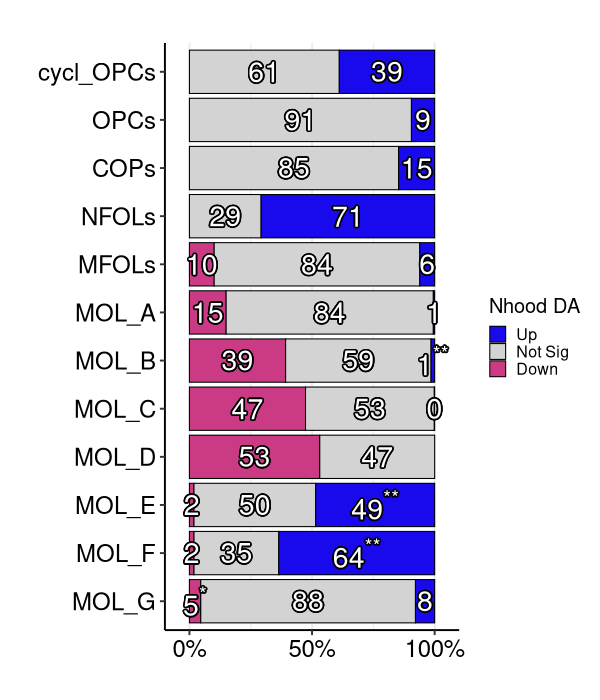

In [45]:
%%R -h 700 -w 600 -i LD

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- LD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )


# Filter sig_results for LD and Up/Down only
sig_results_LD <- sig_results %>%
  filter(condition_with_more == "LD", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)


# For parse labels: build strings like "paste('45%', '^'* )"
plot_df_with_labels <- plot_df %>% 
  left_join(
    sig_results_LD,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.1, 0.1)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_LPC_demyel_SIG.png"),
  plot = p,  # explicitly specify which plot to save
  width = 14,
  height = 10,
  dpi = 300
)

# Display the plot
print(p)

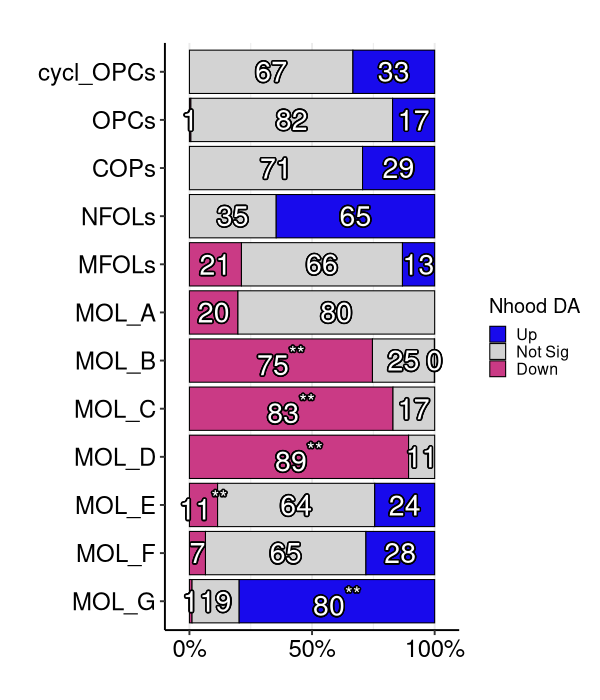

In [46]:
%%R -h 700 -w 600 -i CD

## FINAL PLOT FOR CD ##

# Define desired order (same as before)
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for CD
plot_df <- CD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )


# Filter sig_results for CD and Up/Down only
sig_results_CD <- sig_results %>%
  filter(condition_with_more == "CD", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and prepare labels
plot_df_with_labels <- plot_df %>% 
  left_join(
    sig_results_CD,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.1, 0.1)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_CPZ_demyel_SIG.png"),
  plot = p,
  width = 14,
  height = 10,
  dpi = 300
)

# Display the plot
print(p)

# Complete code with new stats/outputs

In [39]:
%%R -i LD -i CD

LD_df <- LD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    ),
    condition = "LD"
  ) %>%
  group_by(nhood_annotation, sig_status, condition) %>%   # <-- include condition here
  summarise(n = n(), .groups = "drop")

CD_df <- CD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    ),
    condition = "CD"
  ) %>%
  group_by(nhood_annotation, sig_status, condition) %>%   # <-- include condition here
  summarise(n = n(), .groups = "drop")

# Combine dataframes
combined_df <- bind_rows(LD_df, CD_df)

# Compute total counts per cell type and condition
totals_df <- combined_df %>%
  group_by(nhood_annotation, condition) %>%
  summarise(total_n = sum(n), .groups = "drop")

# Merge totals back in
combined_df <- combined_df %>%
  left_join(totals_df, by = c("nhood_annotation", "condition"))

# Function to run appropriate test with manual expected counts check
test_fn <- function(cell, status) {
  sub_df <- combined_df %>%
    filter(nhood_annotation == cell, sig_status == status)
  
  if (nrow(sub_df) != 2) {
    return(tibble(
      nhood_annotation = cell,
      sig_status = status,
      LD_count = NA,
      LD_total = NA,
      LD_prop = NA,
      CD_count = NA,
      CD_total = NA,
      CD_prop = NA,
      p_value = NA,
      test_used = NA
    ))
  }
  
  counts <- sub_df$n
  totals <- sub_df$total_n
  
  mat <- matrix(
    c(
      counts[1], totals[1] - counts[1],
      counts[2], totals[2] - counts[2]
    ),
    nrow = 2,
    byrow = TRUE
  )
  
  # Calculate expected counts manually
  row_totals <- rowSums(mat)
  col_totals <- colSums(mat)
  grand_total <- sum(mat)
  expected <- outer(row_totals, col_totals) / grand_total
  
  # Choose test based on expected counts
  if (any(expected < 5)) {
    test <- fisher.test(mat)
    test_name <- "Fisher"
  } else {
    test <- chisq.test(mat, simulate.p.value = FALSE, correct = FALSE)
    test_name <- "Chi-squared"
  }
  
  tibble(
    nhood_annotation = cell,
    sig_status = status,
    LD_count = counts[1],
    LD_total = totals[1],
    LD_prop = counts[1]/totals[1],
    CD_count = counts[2],
    CD_total = totals[2],
    CD_prop = counts[2]/totals[2],
    p_value = test$p.value,
    test_used = test_name
  )
}

# Unique combinations to test
combinations <- combined_df %>%
  distinct(nhood_annotation, sig_status)

# Run the tests
results <- pmap_dfr(
  list(combinations$nhood_annotation, combinations$sig_status),
  test_fn
)

# Adjust p-values
results <- results %>%
  mutate(p_adj = p.adjust(p_value, method = "BH")) %>%
  mutate(
    condition_with_more = case_when(
      is.na(LD_prop) | is.na(CD_prop) ~ NA_character_,
      LD_prop > CD_prop ~ "LD",
      LD_prop < CD_prop ~ "CD",
      LD_prop == CD_prop ~ "Equal"
    ),
    significance = case_when(
      is.na(p_adj) ~ NA_character_,
      p_adj < 0.01 ~ "** (p < 0.01)",
      p_adj < 0.05 ~ "* (p < 0.05)",
      TRUE ~ ""
    )
  )

# View or save
print(results, n = Inf)
write.csv(results, "pairwise_fisher_chisq_results_demyelination.csv", row.names = FALSE)

# A tibble: 32 × 13
   nhood_annotation sig_status LD_count LD_total LD_prop CD_count CD_total
   <chr>            <chr>         <int>    <int>   <dbl>    <int>    <int>
 1 COPs             Not Sig          29       34  0.853        24       34
 2 COPs             Up                5       34  0.147        10       34
 3 MFOLs            Down             10       99  0.101        21       99
 4 MFOLs            Not Sig          83       99  0.838        65       99
 5 MFOLs            Up                6       99  0.0606       13       99
 6 MOL_A            Down             28      187  0.150        37      187
 7 MOL_A            Not Sig         158      187  0.845       150      187
 8 MOL_A            Up               NA       NA NA            NA       NA
 9 MOL_B            Down            402     1025  0.392       765     1025
10 MOL_B            Not Sig         608     1025  0.593       259     1025
11 MOL_B            Up               15     1025  0.0146        1     1025
12 MO

In [40]:
%%R -i LD
# Check what cell types are actually in LD
print("Cell types in LD:")
print(unique(LD$nhood_annotation))
print("")

# Check if all desired cell types are present
desired_order <- c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
)

print("Missing cell types from desired order:")
missing_types <- setdiff(desired_order, unique(LD$nhood_annotation))
print(missing_types)
print("")

print("Extra cell types not in desired order:")
extra_types <- setdiff(unique(LD$nhood_annotation), desired_order)
print(extra_types)
print("")

# Check the structure of LD
print("Structure of LD:")
str(LD)
print("")

# Check first few rows
print("First few rows of LD:")
head(LD)

[1] "Cell types in LD:"
 [1] "NFOLs"     "MFOLs"     "MOL_E"     "MOL_C"     "OPCs"      "MOL_D"    
 [7] "MOL_B"     "cycl_OPCs" "COPs"      "MOL_A"     "MOL_F"     "MOL_G"    
[1] ""
[1] "Missing cell types from desired order:"
character(0)
[1] ""
[1] "Extra cell types not in desired order:"
character(0)
[1] ""
[1] "Structure of LD:"
'data.frame':	3280 obs. of  12 variables:
 $ Unnamed: 0           : int  0 1 2 3 4 5 6 7 9 11 ...
 $ kth_distance         : num  4.8 3.93 3.59 3.3 2.8 ...
 $ logFC                : num  2.59 1.42 1.88 3.69 2.19 ...
 $ logCPM               : num  8.77 8.72 8.73 9.2 9.09 ...
 $ F                    : num  5.08 1.42 2.58 8.28 3.26 ...
 $ PValue               : num  0.02539 0.23438 0.10997 0.00445 0.07241 ...
 $ FDR                  : num  0.078 0.3528 0.2079 0.0272 0.1557 ...
 $ SpatialFDR           : num  0.073 0.3413 0.1986 0.0251 0.1481 ...
 $ Sig                  : logi  TRUE FALSE FALSE TRUE FALSE TRUE ...
 $ Nhood_size           : num  100 108 113 147

In [41]:
%%R 
# Check what's in the results dataframe
print("Structure of results:")
str(results)
print("")

print("Column names in results:")
print(colnames(results))
print("")

print("Cell types in results:")
print(unique(results$nhood_annotation))
print("")

print("Unique values in condition_with_more:")
print(unique(results$condition_with_more))
print("")

print("Unique values in sig_status:")
print(unique(results$sig_status))
print("")

# Check if there's a mismatch between LD cell types and results cell types
LD_cell_types <- unique(LD$nhood_annotation)
results_cell_types <- unique(results$nhood_annotation)

print("Cell types in LD but not in results:")
print(setdiff(LD_cell_types, results_cell_types))
print("")

print("Cell types in results but not in LD:")
print(setdiff(results_cell_types, LD_cell_types))
print("")

# Check first few rows of results
print("First few rows of results:")
head(results, 10)

[1] "Structure of results:"
tibble [32 × 13] (S3: tbl_df/tbl/data.frame)
 $ nhood_annotation   : chr [1:32] "COPs" "COPs" "MFOLs" "MFOLs" ...
 $ sig_status         : chr [1:32] "Not Sig" "Up" "Down" "Not Sig" ...
 $ LD_count           : int [1:32] 29 5 10 83 6 28 158 NA 402 608 ...
 $ LD_total           : int [1:32] 34 34 99 99 99 187 187 NA 1025 1025 ...
 $ LD_prop            : num [1:32] 0.8529 0.1471 0.101 0.8384 0.0606 ...
 $ CD_count           : int [1:32] 24 10 21 65 13 37 150 NA 765 259 ...
 $ CD_total           : int [1:32] 34 34 99 99 99 187 187 NA 1025 1025 ...
 $ CD_prop            : num [1:32] 0.706 0.294 0.212 0.657 0.131 ...
 $ p_value            : num [1:32] 0.14365 0.14365 0.03146 0.00324 0.09122 ...
 $ test_used          : chr [1:32] "Chi-squared" "Chi-squared" "Chi-squared" "Chi-squared" ...
 $ p_adj              : num [1:32] 0.18936 0.18936 0.05068 0.00626 0.13227 ...
 $ condition_with_more: chr [1:32] "LD" "CD" "CD" "LD" ...
 $ significance       : chr [1:32] "" "" 

In [42]:
%%R -h 700 -w 600 -i LD

## DIAGNOSTIC PLOT CODE ##

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

print("Desired order:")
print(desired_order)
print("")

# Process data
plot_df <- LD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

print("Cell types in plot_df after factoring:")
print(levels(plot_df$nhood_annotation))
print("")

print("Unique cell types in plot_df:")
print(unique(as.character(plot_df$nhood_annotation)))
print("")

# Filter results for LD and Up/Down only
sig_results_LD <- results %>%
  filter(condition_with_more == "LD", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

print("sig_results_LD:")
print(sig_results_LD)
print("")

# Join and check what happens
plot_df_with_labels <- plot_df %>% 
  left_join(
    sig_results_LD,
    by = c("nhood_annotation", "sig_status")
  )

print("Cell types in plot_df_with_labels after join:")
print(levels(plot_df_with_labels$nhood_annotation))
print("")

print("Are factor levels preserved?")
print(identical(levels(plot_df$nhood_annotation), levels(plot_df_with_labels$nhood_annotation)))
print("")

# Check the join results
print("Join results - first 20 rows:")
print(plot_df_with_labels %>% select(nhood_annotation, sig_status, significance) %>% head(20))
print("")

# Continue with the rest of the processing
plot_df_with_labels <- plot_df_with_labels %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
  mutate(
    label = case_when(
      is.na(significance) ~ paste0("'", scales::percent(proportion, accuracy = 1), "'"),
      significance == "* (p < 0.05)" ~ paste0("'", scales::percent(proportion, accuracy = 1), "'^'*'"),
      significance == "** (p < 0.01)" ~ paste0("'", scales::percent(proportion, accuracy = 1), "'^'**'"),
      TRUE ~ paste0("'", scales::percent(proportion, accuracy = 1), "'")
    )
  )

print("Final factor levels before plotting:")
print(levels(plot_df_with_labels$nhood_annotation))
print("")

print("Final data for plotting (first 20 rows):")
print(plot_df_with_labels %>% select(nhood_annotation, sig_status, proportion, label) %>% head(20))

[1] "Desired order:"
 [1] "MOL_G"     "MOL_F"     "MOL_E"     "MOL_D"     "MOL_C"     "MOL_B"    
 [7] "MOL_A"     "MFOLs"     "NFOLs"     "COPs"      "OPCs"      "cycl_OPCs"
[1] ""
[1] "Cell types in plot_df after factoring:"
 [1] "MOL_G"     "MOL_F"     "MOL_E"     "MOL_D"     "MOL_C"     "MOL_B"    
 [7] "MOL_A"     "MFOLs"     "NFOLs"     "COPs"      "OPCs"      "cycl_OPCs"
[1] ""
[1] "Unique cell types in plot_df:"
 [1] "COPs"      "MFOLs"     "MOL_A"     "MOL_B"     "MOL_C"     "MOL_D"    
 [7] "MOL_E"     "MOL_F"     "MOL_G"     "NFOLs"     "OPCs"      "cycl_OPCs"
[1] ""
[1] "sig_results_LD:"
# A tibble: 6 × 3
  nhood_annotation sig_status significance   
  <chr>            <chr>      <chr>          
1 MOL_B            Up         "** (p < 0.01)"
2 MOL_E            Up         "** (p < 0.01)"
3 MOL_F            Up         "** (p < 0.01)"
4 MOL_G            Down       "* (p < 0.05)" 
5 NFOLs            Up         ""             
6 cycl_OPCs        Up         ""             
[1] ""


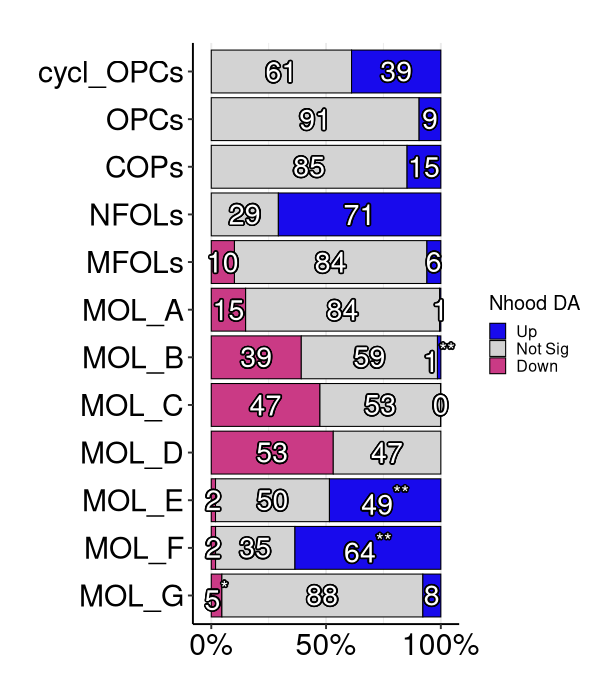

In [43]:
%%R -h 700 -w 600 -i LD

## FINAL PLOT - FIXED ##

# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- LD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LD and Up/Down only
sig_results_LD <- results %>%
  filter(condition_with_more == "LD", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels
plot_df_with_labels <- plot_df %>% 
  left_join(
    sig_results_LD,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_LPC_demyel_SIG_UPDATED.png"),
  plot = p,  # explicitly specify which plot to save
  width = 10,
  height = 10,
  dpi = 300
)

# Display the plot
print(p)

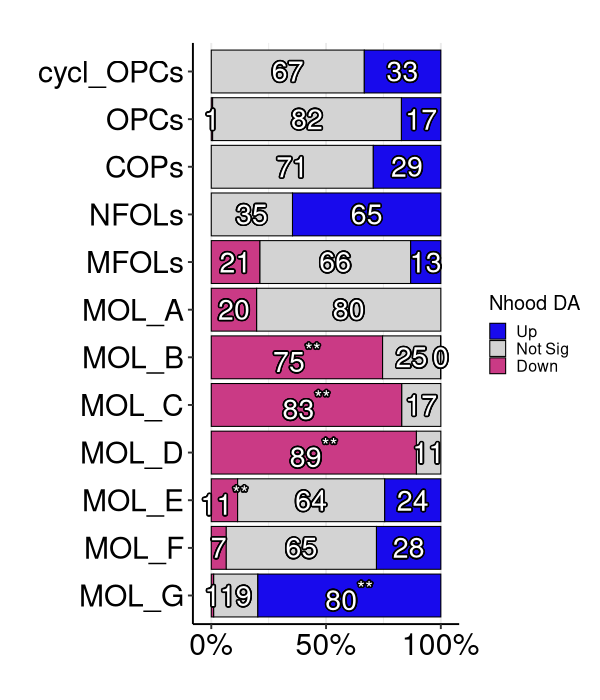

In [44]:
%%R -h 700 -w 600 -i CD
## FINAL PLOT - CD VERSION ##
# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- CD %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for CD and Up/Down only
sig_results_CD <- results %>%
  filter(condition_with_more == "CD", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels
plot_df_with_labels <- plot_df %>% 
  left_join(
    sig_results_CD,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_CD_demyel_SIG_UPDATED.png"),
  plot = p,  # explicitly specify which plot to save
  width = 10,
  height = 10,
  dpi = 300
)

# Display the plot
print(p)

## Now remyel

In [45]:
%%R -i LR -i CR

LR_df <- LR %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  mutate(condition = "LR")

CR_df <- CR %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  mutate(condition = "CR")

# Combine
combined_df <- bind_rows(LR_df, CR_df)

# Compute total counts per cell type and condition
totals_df <- combined_df %>%
  group_by(nhood_annotation, condition) %>%
  summarise(total_n = sum(n), .groups = "drop")

# Merge totals back in
combined_df <- combined_df %>%
  left_join(totals_df, by = c("nhood_annotation", "condition"))

# Function to run Fisher's Exact Test or Chi-squared depending on counts
test_fn <- function(cell, status) {
  sub_df <- combined_df %>%
    filter(nhood_annotation == cell, sig_status == status)
  
  if (nrow(sub_df) != 2) {
    return(tibble(
      nhood_annotation = cell,
      sig_status = status,
      LR_count = NA,
      LR_total = NA,
      LR_prop = NA,
      CR_count = NA,
      CR_total = NA,
      CR_prop = NA,
      p_value = NA,
      test_used = NA
    ))
  }
  
  counts <- sub_df$n
  totals <- sub_df$total_n
  
  mat <- matrix(
    c(
      counts[1], totals[1] - counts[1],
      counts[2], totals[2] - counts[2]
    ),
    nrow = 2,
    byrow = TRUE
  )
  
    # Compute expected counts manually
    row_totals <- rowSums(mat)
    col_totals <- colSums(mat)
    grand_total <- sum(mat)
    expected <- outer(row_totals, col_totals) / grand_total

    # Decide which test to use
    if (any(expected < 5)) {
      test <- fisher.test(mat)
      test_name <- "Fisher"
    } else {
      test <- chisq.test(mat, simulate.p.value = FALSE, correct = FALSE)
      test_name <- "Chi-squared"
    }
  
  tibble(
    nhood_annotation = cell,
    sig_status = status,
    LR_count = counts[1],
    LR_total = totals[1],
    LR_prop = counts[1]/totals[1],
    CR_count = counts[2],
    CR_total = totals[2],
    CR_prop = counts[2]/totals[2],
    p_value = test$p.value,
    test_used = test_name
  )
}

# All unique combinations of cell type and sig_status
combinations <- combined_df %>%
  distinct(nhood_annotation, sig_status)

# Run the tests
results <- pmap_dfr(
  list(combinations$nhood_annotation, combinations$sig_status),
  test_fn
)

# Adjust p-values (BH correction)
results <- results %>%
  mutate(p_adj = p.adjust(p_value, method = "BH"))

# Determine which condition has more (based on proportion)
results <- results %>%
  mutate(
    condition_with_more = case_when(
      is.na(LR_prop) | is.na(CR_prop) ~ NA_character_,
      LR_prop > CR_prop ~ "LR",
      LR_prop < CR_prop ~ "CR",
      LR_prop == CR_prop ~ "Equal"
    )
  )

# Add significance column
results <- results %>%
  mutate(
    significance = case_when(
      is.na(p_adj) ~ NA_character_,
      p_adj < 0.01 ~ "** (p < 0.01)",
      p_adj < 0.05 ~ "* (p < 0.05)",
      TRUE ~ ""
    )
  )

# View the table
print(results, n = Inf)

# Optionally save
write.csv(results, "pairwise_fisher_chisq_results_remyelination.csv", row.names = FALSE)

# A tibble: 26 × 13
   nhood_annotation sig_status LR_count LR_total   LR_prop CR_count CR_total
   <chr>            <chr>         <int>    <int>     <dbl>    <int>    <int>
 1 COPs             Not Sig          34       34  1              34       34
 2 MFOLs            Not Sig          96       99  0.970          92       99
 3 MFOLs            Up                3       99  0.0303          7       99
 4 MOL_A            Down             14      187  0.0749         43      187
 5 MOL_A            Not Sig         173      187  0.925         144      187
 6 MOL_B            Down              1     1025  0.000976      134     1025
 7 MOL_B            Not Sig        1023     1025  0.998         839     1025
 8 MOL_B            Up                1     1025  0.000976       52     1025
 9 MOL_C            Down              9      771  0.0117        182      771
10 MOL_C            Not Sig         762      771  0.988         589      771
11 MOL_D            Down              1      254  0.0039

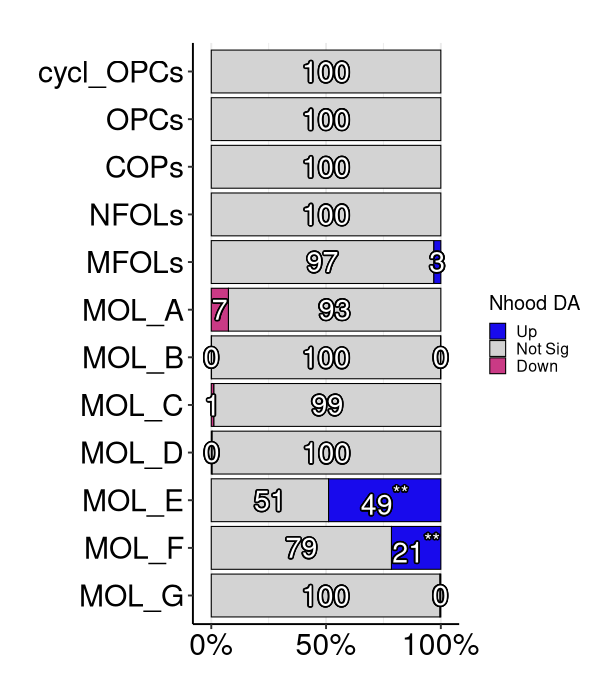

In [46]:
%%R -h 700 -w 600 -i LR

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- LR %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "LR", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_LR_remyel_SIG_UPDATED.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)

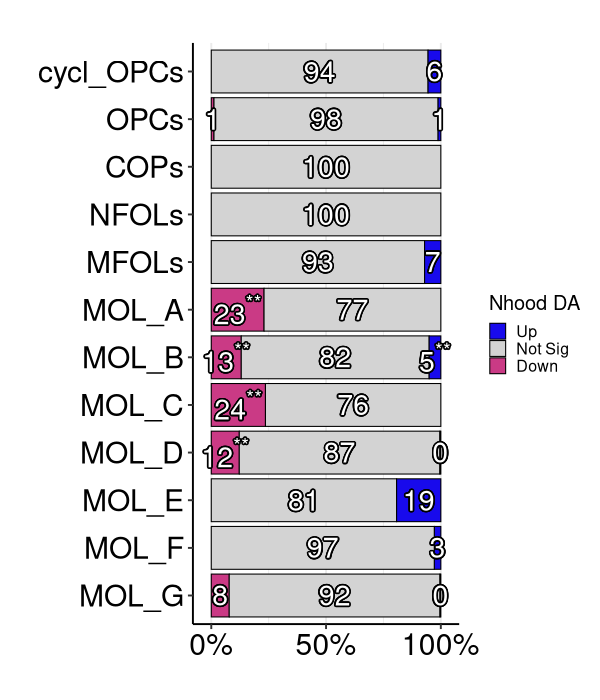

In [47]:
%%R -h 700 -w 600 -i CR

# Process data for CR
plot_df_CR <- CR %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for CR and Up/Down only
sig_results_CR <- results %>%
  filter(condition_with_more == "CR", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for CR
plot_df_with_labels_CR <- plot_df_CR %>% 
  left_join(
    sig_results_CR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p_CR <- ggplot(plot_df_with_labels_CR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the CR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_CR_remyel_SIG_UPDATED.png"),
  plot = p_CR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the CR plot
print(p_CR)

# Individual beeswarm plots

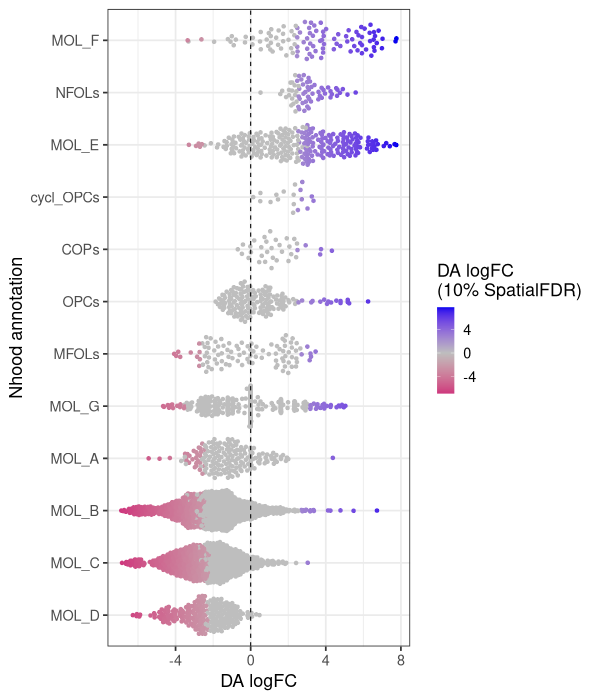

In [16]:
%%R -h 700 -w 600 -i LD

##ORIGINAL CODE

LD %>%
  # filter(nhood_annotation_frac > 0.5) %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(mean_lfc) %>%
  mutate(nhood_annotation = factor(nhood_annotation, levels = unique(nhood_annotation))) %>%
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)') +
  theme_bw(base_size = 18) +
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') + 
  ylab('DA logFC')

# CORRECTED PLOTS!

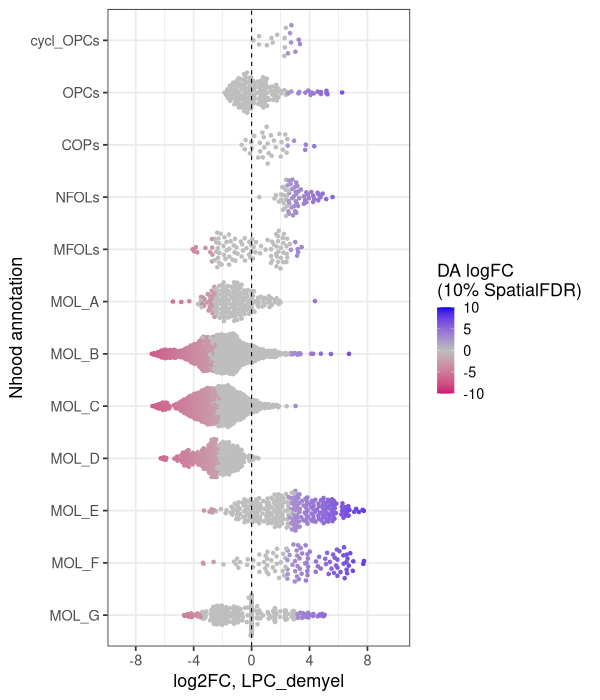

In [17]:
%%R -h 700 -w 600 -i LD

# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

LD %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-10, 10),  # Set color scale limits
    breaks = c(-10, -5, 0, 5, 10),  # Specify breaks on the color scale
    labels = c(-10, -5, 0, 5, 10),  # Specify labels on the color scale
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)'
  ) +
  theme_bw(base_size = 18) +
  scale_y_continuous(limits = c(-9, 10), breaks = c(-4, -8, 0, 4, 8)) +  # Adjust y-axis limits and breaks
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') + 
  ylab('log2FC, LPC_demyel')
  ggsave(paste0(figdir, 'beeswarm_fine_anno_LPC_early_ALL_scaled_REVISION.png'), width = 10, height = 12)

print(last_plot())

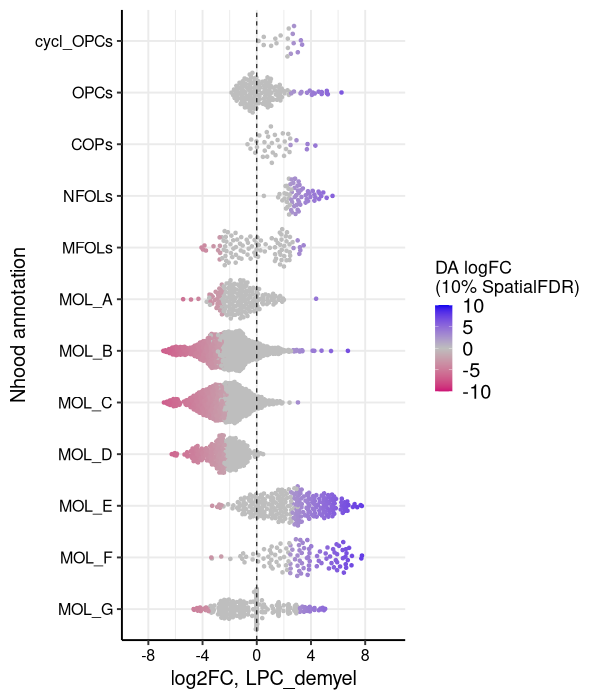

In [18]:
%%R -h 700 -w 600 -i LD

# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))


LD %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-10, 10),  # Set color scale limits
    breaks = c(-10, -5, 0, 5, 10),  # Specify breaks on the color scale
    labels = c(-10, -5, 0, 5, 10),  # Specify labels on the color scale
      
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)'
  ) +
  theme_bw(base_size = 20) +  # Set the global base font size
  theme(
    text = element_text(size = 20, color = "black", family = "sans"),  # Use 'sans' font for consistency
    axis.title = element_text(size = 20, color = "black", family = "sans"),  # Axis titles
    axis.text = element_text(size = 16, color = "black", family = "sans"),   # Axis labels
    legend.text = element_text(size = 20, color = "black", family = "sans"), # Legend text
    legend.title = element_text(size = 18, color = "black", family = "sans"), # Legend title
    panel.border = element_blank(),  # Remove the entire panel border
    axis.line = element_line(color = "black")  # Keep only the axis lines
  ) +
  scale_y_continuous(limits = c(-9, 10), breaks = c(-4, -8, 0, 4, 8)) +  # Adjust y-axis limits and breaks
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') + 
  ylab('log2FC, LPC_demyel')

ggsave(paste0(figdir, 'beeswarm_fine_anno_LPC_early_ALL_scaled_REVISION.png'), width = 10, height = 12)

print(last_plot())

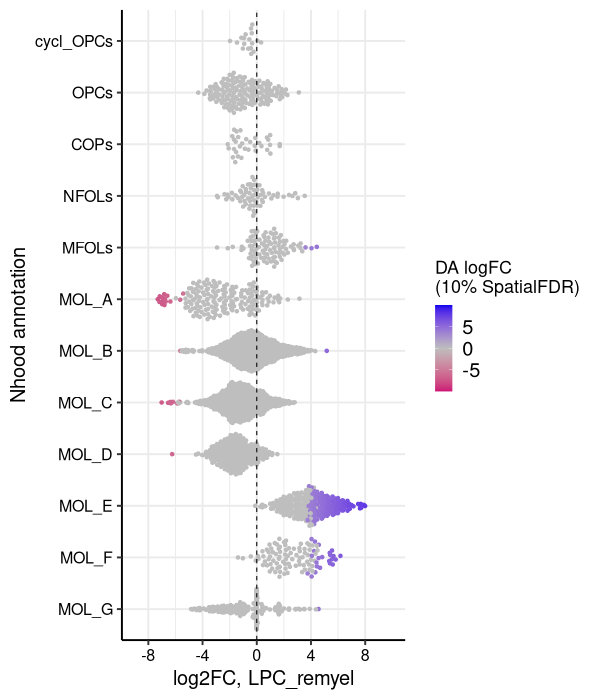

In [19]:
%%R -h 700 -w 600 -i LL

# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))


LL %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-10, 10),  # Set color scale limits
    breaks = c(-5, 0, 5),  # Specify breaks on the color scale
    labels = c(-5, 0, 5),  # Specify labels on the color scale
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)'
  ) +
  theme_bw(base_size = 20) +  # Set the global base font size
  theme(
    text = element_text(size = 20, color = "black", family = "sans"),  # Use 'sans' font for consistency
    axis.title = element_text(size = 20, color = "black", family = "sans"),  # Axis titles
    axis.text = element_text(size = 16, color = "black", family = "sans"),   # Axis labels
    legend.text = element_text(size = 20, color = "black", family = "sans"), # Legend text
    legend.title = element_text(size = 18, color = "black", family = "sans"), # Legend title
    panel.border = element_blank(),  # Remove the entire panel border
    axis.line = element_line(color = "black")  # Keep only the axis lines
  ) +
  scale_y_continuous(limits = c(-9, 10), breaks = c(-4, -8, 0, 4, 8)) +  # Adjust y-axis limits and breaks
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') + 
  ylab('log2FC, LPC_remyel')

ggsave(paste0(figdir, 'beeswarm_fine_anno_LPC_remyel_ALL_scaled_REVISION.png'), width = 10, height = 12)

print(last_plot())

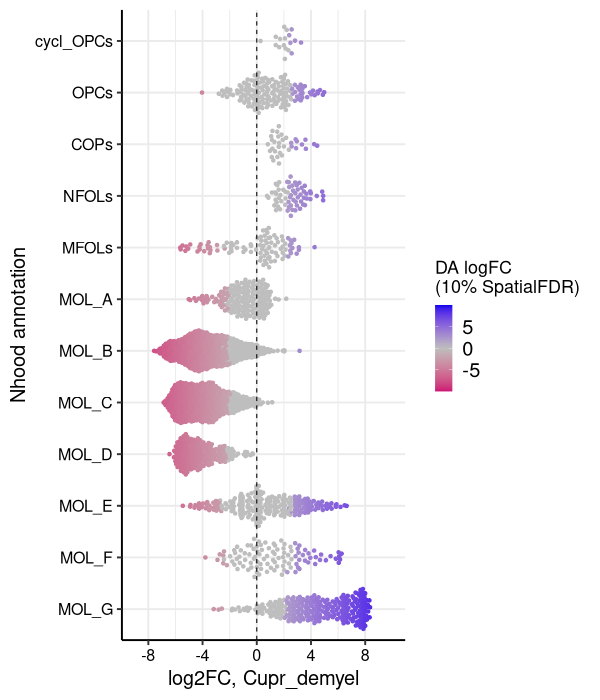

In [21]:
%%R -h 700 -w 600 -i CD

# Define the desired order of nhood_annotation
# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))


CD %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-10, 10),  # Set color scale limits
    breaks = c(-5, 0, 5),  # Specify breaks on the color scale
    labels = c(-5, 0, 5),  # Specify labels on the color scale
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)'
  ) +
  theme_bw(base_size = 20) +  # Set the global base font size
  theme(
    text = element_text(size = 20, color = "black", family = "sans"),  # Use 'sans' font for consistency
    axis.title = element_text(size = 20, color = "black", family = "sans"),  # Axis titles
    axis.text = element_text(size = 16, color = "black", family = "sans"),   # Axis labels
    legend.text = element_text(size = 20, color = "black", family = "sans"), # Legend text
    legend.title = element_text(size = 18, color = "black", family = "sans"), # Legend title
    panel.border = element_blank(),  # Remove the entire panel border
    axis.line = element_line(color = "black")  # Keep only the axis lines
  ) +
  scale_y_continuous(limits = c(-9, 10), breaks = c(-4, -8, 0, 4, 8)) +  # Adjust y-axis limits and breaks
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') + 
  ylab('log2FC, Cupr_demyel')

ggsave(paste0(figdir, 'beeswarm_fine_anno_Cupr_demyel_ALL_scaled_REVISION.png'), width = 10, height = 12)

print(last_plot())

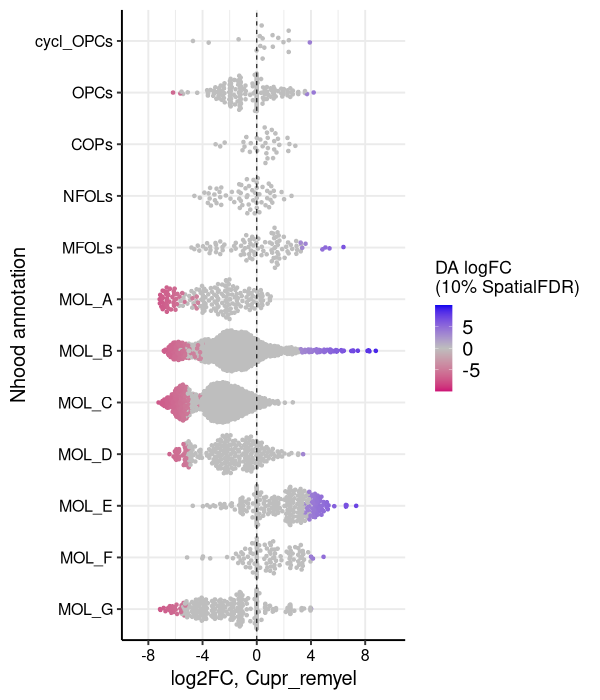

In [22]:
%%R -h 700 -w 600 -i CR

# Define the desired order of nhood_annotation
# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))


CR %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-10, 10),  # Set color scale limits
    breaks = c(-5, 0, 5),  # Specify breaks on the color scale
    labels = c(-5, 0, 5),  # Specify labels on the color scale
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)'
  ) +
  theme_bw(base_size = 20) +  # Set the global base font size
  theme(
    text = element_text(size = 20, color = "black", family = "sans"),  # Use 'sans' font for consistency
    axis.title = element_text(size = 20, color = "black", family = "sans"),  # Axis titles
    axis.text = element_text(size = 16, color = "black", family = "sans"),   # Axis labels
    legend.text = element_text(size = 20, color = "black", family = "sans"), # Legend text
    legend.title = element_text(size = 18, color = "black", family = "sans"), # Legend title
    panel.border = element_blank(),  # Remove the entire panel border
    axis.line = element_line(color = "black")  # Keep only the axis lines
  ) +
  scale_y_continuous(limits = c(-9, 10), breaks = c(-4, -8, 0, 4, 8)) +  # Adjust y-axis limits and breaks
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') + 
  ylab('log2FC, Cupr_remyel')

ggsave(paste0(figdir, 'beeswarm_fine_anno_Cupr_remyel_ALL_scaled_REVISION.png'), width = 10, height = 12)

print(last_plot())

# Formatting?

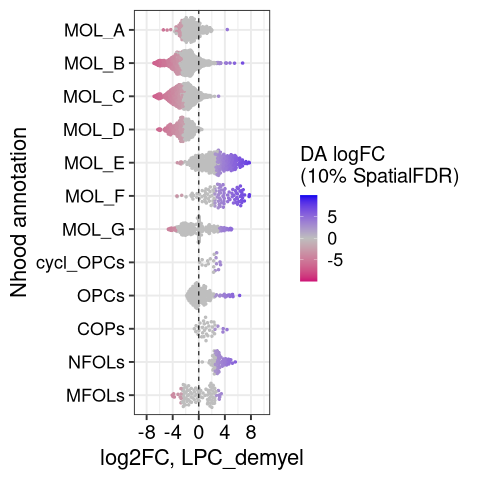

In [28]:
%%R

LD %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%
  ggplot(aes(nhood_annotation, logFC, color = signif)) +
  ggbeeswarm::geom_quasirandom(size = 1) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-10, 10),
    breaks = c(-5, 0, 5),
    labels = c(-5, 0, 5),
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)'
  ) +
  theme_bw(base_size = 20) +
  scale_y_continuous(limits = c(-9, 10), breaks = c(-8, -4, 0, 4, 8)) +
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') +
  ylab('log2FC, LPC_demyel') +
  theme(
    axis.text.x = element_text(size = 20, color = "black"),  # Change x-axis text to black
    axis.text.y = element_text(size = 18, color = "black"),  # Change y-axis text to black
    axis.title.x = element_text(size = 22, color = "black"), # Change x-axis title to black
    axis.title.y = element_text(size = 22, color = "black"), # Change y-axis title to black
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 18)
  )


# Save the plot
ggsave(paste0(figdir, 'beeswarm_fine_anno_LPC_early_ALL_scaled_NEW.png'), width = 14, height = 14)

print(last_plot())

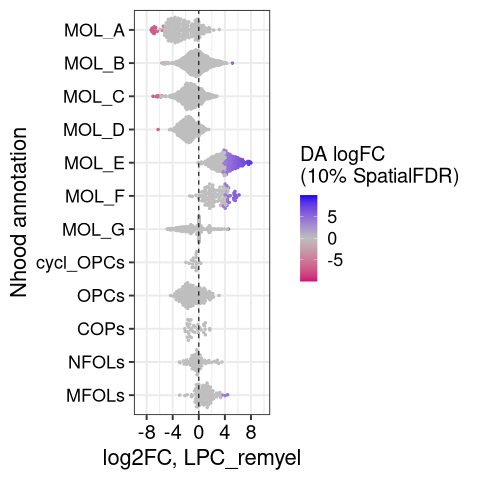

In [29]:
%%R

LL %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%
  ggplot(aes(nhood_annotation, logFC, color = signif)) +
  ggbeeswarm::geom_quasirandom(size = 1) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-10, 10),
    breaks = c(-5, 0, 5),
    labels = c(-5, 0, 5),
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)'
  ) +
  theme_bw(base_size = 20) +
  scale_y_continuous(limits = c(-9, 10), breaks = c(-8, -4, 0, 4, 8)) +
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') +
  ylab('log2FC, LPC_remyel') +
  theme(
    axis.text.x = element_text(size = 20, color = "black"),  # Change x-axis text to black
    axis.text.y = element_text(size = 18, color = "black"),  # Change y-axis text to black
    axis.title.x = element_text(size = 22, color = "black"), # Change x-axis title to black
    axis.title.y = element_text(size = 22, color = "black"), # Change y-axis title to black
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 18)
  )

ggsave(paste0(figdir, 'beeswarm_fine_anno_LPC_remyel_ALL_scaled_NEW.png'), width = 14, height = 14)

print(last_plot())

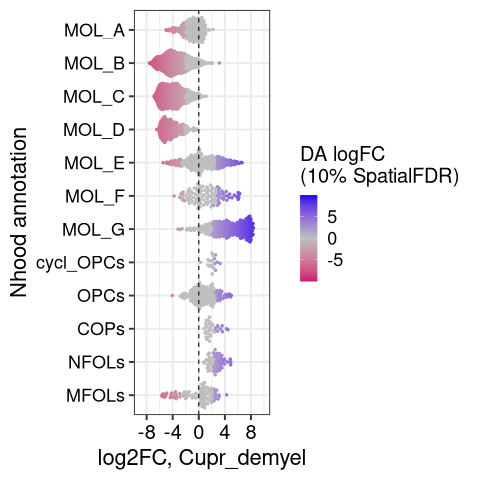

In [30]:
%%R

CD %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%
  ggplot(aes(nhood_annotation, logFC, color = signif)) +
  ggbeeswarm::geom_quasirandom(size = 1) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-10, 10),
    breaks = c(-5, 0, 5),
    labels = c(-5, 0, 5),
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)'
  ) +
  theme_bw(base_size = 20) +
  scale_y_continuous(limits = c(-9, 10), breaks = c(-8, -4, 0, 4, 8)) +
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') +
  ylab('log2FC, Cupr_demyel') +
  theme(
    axis.text.x = element_text(size = 20, color = "black"),  # Change x-axis text to black
    axis.text.y = element_text(size = 18, color = "black"),  # Change y-axis text to black
    axis.title.x = element_text(size = 22, color = "black"), # Change x-axis title to black
    axis.title.y = element_text(size = 22, color = "black"), # Change y-axis title to black
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 18)
  )

ggsave(paste0(figdir, 'beeswarm_fine_anno_Cupr_demyel_ALL_scaled_NEW.png'), width = 14, height = 14)

print(last_plot())

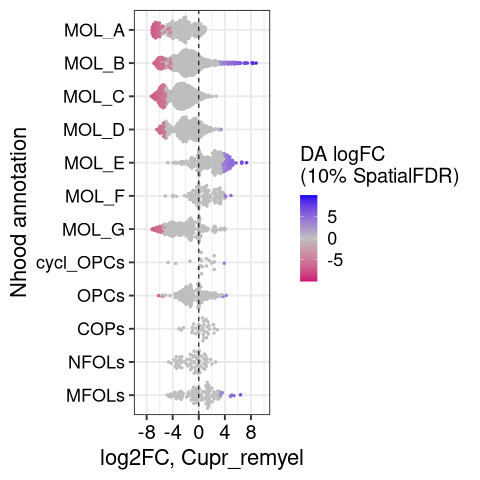

In [35]:
%%R

CR %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%
  ggplot(aes(nhood_annotation, logFC, color = signif)) +
  ggbeeswarm::geom_quasirandom(size = 1) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-10, 10),
    breaks = c(-5, 0, 5),
    labels = c(-5, 0, 5),
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)'
  ) +
  theme_bw(base_size = 20) +
  scale_y_continuous(limits = c(-9, 10), breaks = c(-8, -4, 0, 4, 8)) +
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') +
  ylab('log2FC, Cupr_remyel') +
  theme(
    axis.text.x = element_text(size = 20, color = "black"),  # Change x-axis text to black
    axis.text.y = element_text(size = 18, color = "black"),  # Change y-axis text to black
    axis.title.x = element_text(size = 22, color = "black"), # Change x-axis title to black
    axis.title.y = element_text(size = 22, color = "black"), # Change y-axis title to black
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 18)
  )

ggsave(paste0(figdir, 'beeswarm_fine_anno_Cupr_remyel_ALL_scaled_NEW.png'), width = 14, height = 14)

print(last_plot())

# Now add changes to additional data

In [ ]:
%%R -h 700 -w 600 -i LL

# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", 
    "MOL_F", "MOL_G", "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs"
))


LL %>%
  # filter(nhood_annotation_frac > 0.5) %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)') +
  theme_bw(base_size = 18) +
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') + 
  ylab('DA logFC')


In [ ]:
%%R -h 700 -w 600 -i CD

# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "MOL4_DAO1", "MOL2_DAO1", "MOL1_DAO2", "cycling", "OPCs", 
    "COPs", "NFOLs", "MFOLs", "Mixed", "MOL1", "MOL2", "MOL3", "MOL4"
))


CD %>%
  # filter(nhood_annotation_frac > 0.5) %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)') +
  theme_bw(base_size = 18) +
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') + 
  ylab('DA logFC')

In [ ]:
%%R -h 700 -w 600 -i CR

# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "MOL4_DAO1", "MOL2_DAO1", "MOL1_DAO2", "cycling", "OPCs", 
    "COPs", "NFOLs", "MFOLs", "Mixed", "MOL1", "MOL2", "MOL3", "MOL4"
))


CR %>%
  # filter(nhood_annotation_frac > 0.5) %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)') +
  theme_bw(base_size = 18) +
  geom_hline(yintercept = 0, linetype = 2) +
  xlab('Nhood annotation') + 
  ylab('DA logFC')

## CORRECTED PLOTS!-- EDITED FOR SCALES

In addition: Warning message:
The `guide` argument in `scale_*()` cannot be `FALSE`. This was deprecated in
ggplot2 3.3.4.
ℹ Please use "none" instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


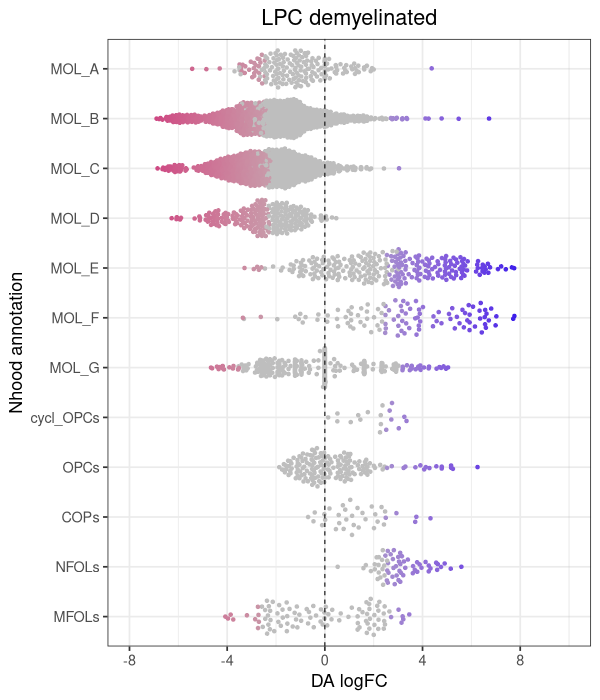

In [29]:
%%R -h 700 -w 600 -i LD

# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", 
    "MOL_F", "MOL_G", "cycl_OPCs", "OPCs", "COPs", "NFOLs", "MFOLs"
))

LD %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-7, 8.5),  # Set color scale limits
    breaks = c(-5, 0, 5),  # Specify breaks on the color scale
    labels = c(-5, 0, 5),  # Specify labels on the color scale
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)', guide=FALSE) +
  theme_bw(base_size = 18) +
  scale_y_continuous(limits = c(-8, 10), breaks = c(-4, -8, 0, 4, 8)) +  # Adjust y-axis limits and breaks
  geom_hline(yintercept = 0, linetype = 2) +
  geom_hline(yintercept = 10, linetype = 'solid', color = 'grey', alpha=0.3) +  # Add vertical line at x = 10
  xlab('Nhood annotation') + 
  ylab('DA logFC') +
  labs(title = "LPC demyelinated") +
  theme(plot.title = element_text(hjust = 0.5))
  ggsave(paste0(figdir, 'beeswarm_fine_anno_LPC_demyel_ALL_scaled_NEW.png'), width = 10, height = 12)

print(last_plot())

In [ ]:
%%R -h 700 -w 600 -i LL

# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "MOL4_DAO1", "MOL2_DAO1", "MOL1_DAO2", "cycling", "OPCs", 
    "COPs", "NFOLs", "MFOLs", "Mixed", "MOL1", "MOL2", "MOL3", "MOL4"
))

LL %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-7, 8.5),  # Set color scale limits
    breaks = c(-5, 0, 5),  # Specify breaks on the color scale
    labels = c(-5, 0, 5),  # Specify labels on the color scale
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)', guide=FALSE) +
  theme_bw(base_size = 18) +
  scale_y_continuous(limits = c(-8, 10), breaks = c(-4, -8, 0, 4, 8)) +  # Adjust y-axis limits and breaks
  geom_hline(yintercept = 0, linetype = 2) +
  geom_hline(yintercept = 10, linetype = 'solid', color = 'grey', alpha=0.3) +  # Add vertical line at x = 10
  xlab('Nhood annotation') + 
  ylab('DA logFC') +
  labs(title = "LPC remyelinated (late)") +
  theme(plot.title = element_text(hjust = 0.5)) +
  theme(axis.title.y = element_blank())  # Remove Y-axis label
  ggsave(paste0(figdir, 'beeswarm_fine_anno_LPC_late_ALL_scaled.png'), width = 10, height = 12)

print(last_plot())

In [ ]:
%%R -h 700 -w 600 -i CD

# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "MOL4_DAO1", "MOL2_DAO1", "MOL1_DAO2", "cycling", "OPCs", 
    "COPs", "NFOLs", "MFOLs", "Mixed", "MOL1", "MOL2", "MOL3", "MOL4"
))

CD %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-7, 8.5),  # Set color scale limits
    breaks = c(-5, 0, 5),  # Specify breaks on the color scale
    labels = c(-5, 0, 5),  # Specify labels on the color scale
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)', guide=FALSE) +
  theme_bw(base_size = 18) +
  scale_y_continuous(limits = c(-8, 10), breaks = c(-4, -8, 0, 4, 8)) +  # Adjust y-axis limits and breaks
  geom_hline(yintercept = 0, linetype = 2) +
  geom_hline(yintercept = 10, linetype = 'solid', color = 'grey', alpha=0.3) +  # Add vertical line at x = 10
  xlab('Nhood annotation') + 
  ylab('DA logFC') +
  labs(title = "Cupr demyelinated") +
  theme(plot.title = element_text(hjust = 0.5)) +
  theme(axis.title.y = element_blank())  # Remove Y-axis label
  ggsave(paste0(figdir, 'beeswarm_fine_anno_cupr_demyel_ALL_scaled.png'), width = 10, height = 12)

print(last_plot())

In [ ]:
%%R -h 700 -w 600 -i CR

# Define the desired order of nhood_annotation
desired_order <- rev(c(
    "MOL4_DAO1", "MOL2_DAO1", "MOL1_DAO2", "cycling", "OPCs", 
    "COPs", "NFOLs", "MFOLs", "Mixed", "MOL1", "MOL2", "MOL3", "MOL4"
))

CR %>%
  mutate(signif = ifelse(SpatialFDR < 0.1, logFC, 0)) %>%
  group_by(nhood_annotation) %>%
  mutate(mean_lfc_val = ifelse(!is.na(signif), logFC, 0)) %>%
  mutate(mean_lfc = mean(mean_lfc_val)) %>%
  ungroup() %>%
  arrange(factor(nhood_annotation, levels = desired_order)) %>%  # Arrange by desired order
  mutate(nhood_annotation = factor(nhood_annotation, levels = desired_order)) %>%  # Reorder factor levels
  ggplot(aes(nhood_annotation, logFC, color = signif)) + 
  ggbeeswarm::geom_quasirandom(size = 1.5) +
  coord_flip() +
  scale_color_gradient2(
    limits = c(-7, 8.5),  # Set color scale limits
    breaks = c(-5, 0, 5),  # Specify breaks on the color scale
    labels = c(-5, 0, 5),  # Specify labels on the color scale
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)', guide=FALSE) +
  theme_bw(base_size = 18) +
  scale_y_continuous(limits = c(-8, 10), breaks = c(-4, -8, 0, 4, 8)) +  # Adjust y-axis limits and breaks
  geom_hline(yintercept = 0, linetype = 2) +
  geom_hline(yintercept = 10, linetype = 'solid', color = 'grey', alpha=0.3) +  # Add vertical line at x = 10
  xlab('Nhood annotation') + 
  ylab('DA logFC') +
  labs(title = "Cupr remyelinated") +
  theme(plot.title = element_text(hjust = 0.5)) +
  theme(axis.title.y = element_blank())  # Remove Y-axis label
  ggsave(paste0(figdir, 'beeswarm_fine_anno_cupr_remyel_ALL_scaled.png'), width = 10, height = 12)

print(last_plot())

In [ ]:
%%R -h 700 -w 600

# Define a basic plot with no data, just for the color scale
color_scale_plot <- ggplot() +
  scale_color_gradient2(
    limits = c(-7, 8.5),  # Set color scale limits
    breaks = c(-5, 0, 5),  # Specify breaks on the color scale
    labels = c(-5, 0, 5),  # Specify labels on the color scale
    high = 'blue2', mid = 'grey', low = 'deeppink3', name = 'DA logFC\n(10% SpatialFDR)'
  ) +
  theme_minimal()

# Save the color scale plot
ggsave("./sysVI_mm_OL_figures/color_scale_plot.png", plot = color_scale_plot, width = 6, height = 4)